In [ ]:
import pandas as pd
import gdown
import zipfile
import os
import numpy as np

# 1. Descargar el archivo ZIP desde Google Drive
file_id_zip = "12cddE9A2FdHDQj5n5DjnpR7z8vk8Zhtj" # Reemplaza esto con el ID real de tu .zip
url_zip = f"https://drive.google.com/uc?id={file_id_zip}"

print("Descargando el archivo ZIP...")
gdown.download(url_zip, "datos_proyecto.zip", quiet=False)

# 2. Descomprimir el archivo localmente en Colab
print("\nDescomprimiendo archivos...")
with zipfile.ZipFile("datos_proyecto.zip", 'r') as zip_ref:
    # Esto crea una carpeta llamada 'datos_extraidos' y mete los CSV ahí
    zip_ref.extractall("datos_extraidos")

# (Opcional) Ver qué archivos se extrajeron para confirmar
print("\nArchivos listos en la carpeta local:")
print(os.listdir("datos_extraidos"))

# 3. Cargar los datos a Pandas
# Usamos la nueva ruta local donde se descomprimieron los archivos
BASE_PATH = "datos_extraidos/Data_General_SIN_PROCESAR/"

print("\nCargando DataFrames...")
matches = pd.read_csv(f"{BASE_PATH}pl_24-25_matches_clean.csv", parse_dates=["date"])
home_away = pd.read_csv(f"{BASE_PATH}overwiev__results2024-202591_home_away.csv")
overall = pd.read_csv(f"{BASE_PATH}overwiev__results2024-202591_overall.csv")
shoot_for = pd.read_csv(f"{BASE_PATH}overwiev__stats_squads_shooting_for.csv")
shoot_against = pd.read_csv(f"{BASE_PATH}overwiev__stats_squads_shooting_against.csv")
std_for = pd.read_csv(f"{BASE_PATH}overwiev__stats_squads_standard_for.csv")
std_against = pd.read_csv(f"{BASE_PATH}overwiev__stats_squads_standard_against.csv")
keeper_for = pd.read_csv(f"{BASE_PATH}overwiev__stats_squads_keeper_for.csv")
keeper_against = pd.read_csv(f"{BASE_PATH}overwiev__stats_squads_keeper_against.csv")
misc_for = pd.read_csv(f"{BASE_PATH}overwiev__stats_squads_misc_for.csv")
players = pd.read_csv(f"{BASE_PATH}Squad_PlayerStats__stats_standard.csv")

print("¡Todo cargado con éxito y listo para trabajar!")

# normalizar nombres de equipos
def norm(s):
    return s.strip()


for df_temp in [matches, home_away, overall, shoot_for, shoot_against, std_for, std_against, keeper_for, keeper_against, misc_for]:
    if 'Squad' in df_temp.columns:
        df_temp['Squad'] = df_temp['Squad'].astype(str).map(norm)


matches['home_team'] = matches['home_team'].astype(str).map(norm)
matches['away_team'] = matches['away_team'].astype(str).map(norm)


# 2) targets desde score
matches['score'] = matches['score'].str.replace('–', '-', regex=False)


matches[['target_home_goals','target_away_goals']] = (
    matches['score']
    .str.split('-', expand=True)
    .astype(int)
)


matches['target_result'] = np.sign(
    matches['target_home_goals'] - matches['target_away_goals']
).fillna(0).astype(int)


# 3) rolling por equipo
N = 5
matches = matches.sort_values("date").reset_index(drop=True)


home_df = matches[['id','date','home_team','target_home_goals','target_away_goals','home_xg']].rename(
    columns={
        'id':'match_id',
        'home_team':'team',
        'target_home_goals':'goals_for',
        'target_away_goals':'goals_against',
        'home_xg':'xG'
    }
)
home_df['is_home'] = 1


away_df = matches[['id','date','away_team','target_away_goals','target_home_goals','away_xg']].rename(
    columns={
        'id':'match_id',
        'away_team':'team',
        'target_away_goals':'goals_for',
        'target_home_goals':'goals_against',
        'away_xg':'xG'
    }
)
away_df['is_home'] = 0


team_matches = pd.concat([home_df, away_df], ignore_index=True).sort_values(['team','date'])


# puntos
team_matches['points'] = team_matches.apply(
    lambda r: 3 if r['goals_for'] > r['goals_against']
    else (1 if r['goals_for'] == r['goals_against'] else 0),
    axis=1
)


# ✅ rolling SUMA últimos 5 previos (corrected aggregation functions)
team_matches['goals_for_last5'] = team_matches.groupby('team')['goals_for'].apply(
    lambda s: s.shift().rolling(N, min_periods=1).sum()
).reset_index(level=0, drop=True)


team_matches['goals_against_last5'] = team_matches.groupby('team')['goals_against'].apply(
    lambda s: s.shift().rolling(N, min_periods=1).sum()
).reset_index(level=0, drop=True)


team_matches['xG_last5'] = team_matches.groupby('team')['xG'].apply(
    lambda s: s.shift().rolling(N, min_periods=1).mean()
).reset_index(level=0, drop=True)


team_matches['pts_last5'] = team_matches.groupby('team')['points'].apply(
    lambda s: s.shift().rolling(N, min_periods=1).sum()
).reset_index(level=0, drop=True)


# rest days
team_matches['prev_date'] = team_matches.groupby('team')['date'].shift()
team_matches['rest_days'] = (team_matches['date'] - team_matches['prev_date']).dt.days
team_matches['rest_days'] = team_matches['rest_days'].fillna(999)


# pivot home / away
home_features = (
    team_matches[team_matches['is_home']==1]
    .set_index('match_id')[['goals_for_last5','goals_against_last5','xG_last5','pts_last5','rest_days']]
    .add_prefix('home_')
)


away_features = (
    team_matches[team_matches['is_home']==0]
    .set_index('match_id')[['goals_for_last5','goals_against_last5','xG_last5','pts_last5','rest_days']]
    .add_prefix('away_')
)


mega = matches.set_index('id').join(home_features).join(away_features).reset_index()


# 4) features temporada
home_agg = home_away.set_index('Squad')[['Home_Pts/MP','Home_xG','Home_GF','Home_GA']] \
    .rename(columns=lambda c: 'home_season_' + c)


away_agg = home_away.set_index('Squad')[['Away_Pts/MP','Away_xG','Away_GF','Away_GA']] \
    .rename(columns=lambda c: 'away_season_' + c)


mega['home_team_norm'] = mega['home_team'].map(norm)
mega['away_team_norm'] = mega['away_team'].map(norm)


mega = mega.join(home_agg, on='home_team_norm').join(away_agg, on='away_team_norm')


# 5) diferenciales
mega['diff_pts_per_match_season'] = (
    mega['home_season_Home_Pts/MP'] - mega['away_season_Away_Pts/MP']
)


# guardar
mega.to_csv("megatabla_features.csv", index=False)
print("Megatabla creada: megatabla_features.csv, shape:", mega.shape)

Descargando el archivo ZIP...


Downloading...
From: https://drive.google.com/uc?id=12cddE9A2FdHDQj5n5DjnpR7z8vk8Zhtj
To: /content/datos_proyecto.zip
100%|██████████| 3.40M/3.40M [00:00<00:00, 88.7MB/s]



Descomprimiendo archivos...

Archivos listos en la carpeta local:
['Data_General_SIN_PROCESAR']

Cargando DataFrames...
¡Todo cargado con éxito y listo para trabajar!
Megatabla creada: megatabla_features.csv, shape: (380, 39)


El dataset tiene 380 partidos y 29 columnas.


,id,score,away_goals_against_last5,target_result,target_home_goals,target_away_goals,home_xG_last5,home_xg,home_season_Home_xG,home_season_Home_Pts/MP,...,away_xg,away_season_Away_xG,away_season_Away_Pts/MP,away_season_Away_GF,away_season_Away_GA,away_pts_last5,away_goals_for_last5,away_rest_days,away_team,home_team
0,1,1-0,0,1,1,0,0.0,2.4,30.0,1.26,...,0.4,26.9,1.47,27,24,0,0,13,Fulham,Manchester Utd
1,2,0-2,0,-1,0,2,0.0,0.5,16.8,0.37,...,2.6,41.7,2.00,44,25,0,0,13,Liverpool,Ipswich Town
2,3,1-0,0,1,1,0,0.0,0.3,0.0,0.00,...,1.8,15.4,0.32,13,39,0,0,13,Southampton,Newcastle Utd
3,4,0-3,0,-1,0,3,0.0,0.5,23.1,1.26,...,1.4,28.0,1.53,36,33,0,0,13,Brighton,Everton
4,5,1-1,0,0,1,1,0.0,1.3,0.0,0.00,...,1.2,32.7,1.47,35,30,0,0,13,Bournemouth,Nott'ham Forest


Columnas eliminadas para evitar fuga de datos: ['target_home_goals', 'target_away_goals', 'score', 'id', 'away_team', 'home_team']
Partidos para entrenar (Train): 280
Partidos para evaluar (Test): 100
Datos escalados correctamente. ¡La tabla está lista para el modelo!


,away_goals_against_last5,home_xG_last5,home_xg,home_season_Home_xG,home_season_Home_Pts/MP,home_season_Home_GF,home_season_Home_GA,home_rest_days,home_pts_last5,home_goals_for_last5,...,diff_pts_per_match_season,away_xG_last5,away_xg,away_season_Away_xG,away_season_Away_Pts/MP,away_season_Away_GF,away_season_Away_GA,away_pts_last5,away_goals_for_last5,away_rest_days
0,-1.877516,-2.568505,1.035464,0.554702,0.112444,0.039043,0.462655,1.572125,-1.665025,-1.830953,...,-0.547718,-2.542818,-1.132713,0.538553,0.692082,0.429218,0.065598,-1.744604,-1.889523,1.562181
1,-1.877516,-2.568505,-1.258859,-0.444313,-0.998618,-0.604017,1.637652,1.572125,-1.665025,-1.830953,...,-2.808179,-2.542818,1.476678,1.781528,1.519281,1.763693,0.140263,-1.744604,-1.889523,1.562181
2,-1.877516,-2.568505,-1.500367,-1.715786,-1.460519,-1.604332,-1.593589,1.572125,-1.665025,-1.830953,...,-0.213425,-2.542818,0.527809,-0.427273,-1.102783,-0.669760,1.185569,-1.744604,-1.889523,1.562181
3,-1.877516,-2.568505,-1.258859,0.032490,0.112444,0.253396,0.095468,1.572125,-1.665025,-1.830953,...,-0.643231,-2.542818,0.053374,0.630936,0.785728,1.135705,0.737580,-1.744604,-1.889523,1.562181
4,-1.877516,-2.568505,-0.292828,-1.715786,-1.460519,-1.604332,-1.593589,1.572125,-1.665025,-1.830953,...,-0.213425,-2.542818,-0.183843,1.025665,0.692082,1.057206,0.513586,-1.744604,-1.889523,1.562181


Entrenando el Modelo XGBoost... (esto puede tomar unos segundos)
¡Entrenamiento completado!
Predicciones de XGBoost generadas con éxito.


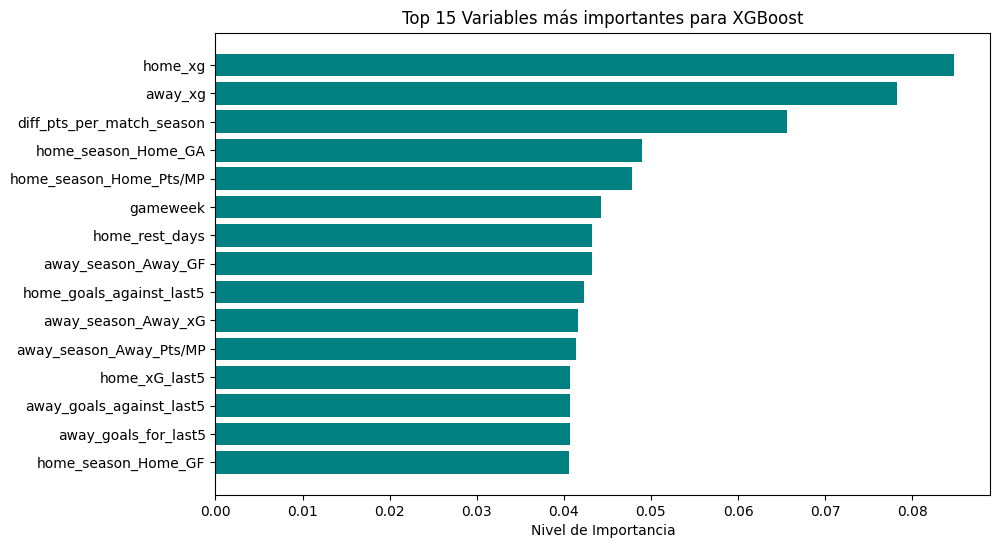

=== MÉTRICAS DE EVALUACIÓN DEL MODELO XGBoost ===

Accuracy (Precisión): 54.00%
Log Loss: 1.1045

--------------------------------------------------

Reporte detallado por tipo de resultado:
                     precision    recall  f1-score   support

Gana Visitante (-1)       0.49      0.64      0.55        33
         Empate (0)       0.33      0.17      0.22        24
     Gana Local (1)       0.64      0.67      0.66        43

           accuracy                           0.54       100
          macro avg       0.49      0.49      0.48       100
       weighted avg       0.52      0.54      0.52       100


--------------------------------------------------



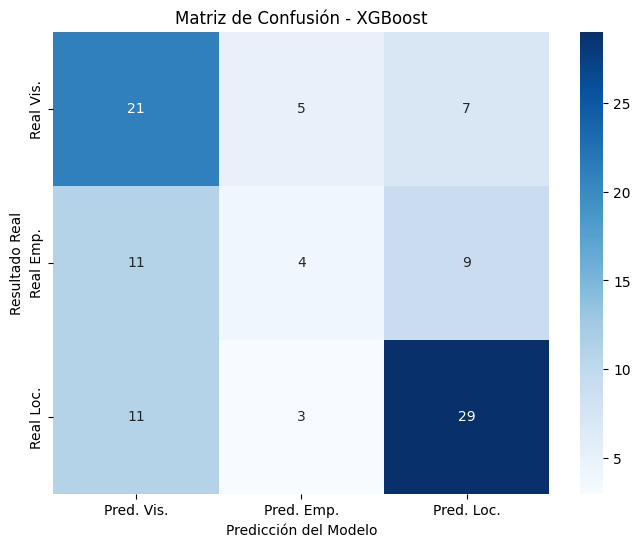

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

BASE_PATH = "/content/datos_extraidos/Data_General_SIN_PROCESAR/"
# 1. Cargar los datos (Asegúrate de subir el archivo a tu Colab primero)
# Cambia 'megatabla_premier.csv' por el nombre real de tu archivo
df = pd.read_csv(f"{BASE_PATH}data_limpiav3.csv")


# Vistazo rápido para confirmar que todo cargó bien
print(f"El dataset tiene {df.shape[0]} partidos y {df.shape[1]} columnas.")
display(df.head())
# Hacemos una copia por seguridad
df_clean = df.copy()


# Columnas que DEBEMOS borrar para evitar que el modelo haga trampa
columnas_fuga = ['target_home_goals', 'target_away_goals', 'score']


# Columnas que no sirven para predecir (identificadores)
columnas_inutiles = ['id','dayofweek','away_team','home_team']


# Eliminamos todas esas columnas si existen en el DataFrame
columnas_a_borrar = [col for col in (columnas_fuga + columnas_inutiles) if col in df_clean.columns]
df_clean = df_clean.drop(columns=columnas_a_borrar)


print(f"Columnas eliminadas para evitar fuga de datos: {columnas_a_borrar}")
# Definimos X (Características) e y (Objetivo)
X = df_clean.drop(columns=['target_result'])
y = df_clean['target_result']


# Definimos en qué jornada (Gameweek) cortamos.
# Si la Premier tiene 38 jornadas, entrenamos con las primeras 28 y probamos con las últimas 10.
corte_jornada = 28


# Creamos máscaras booleanas basadas en la jornada
train_mask = X['gameweek'] <= corte_jornada
test_mask = X['gameweek'] > corte_jornada


# Dividimos X
X_train = X[train_mask].copy()
X_test = X[test_mask].copy()


# Dividimos y
y_train = y[train_mask].copy()
y_test = y[test_mask].copy()


# Podemos borrar la columna 'Gameweek' de X si creemos que no ayuda a predecir
# X_train = X_train.drop(columns=['Gameweek'])
# X_test = X_test.drop(columns=['Gameweek'])


print(f"Partidos para entrenar (Train): {X_train.shape[0]}")
print(f"Partidos para evaluar (Test): {X_test.shape[0]}")
# Identificamos las columnas que son numéricas y no son las codificadas (0 y 1)
# Descartamos las variables binarias y de jornadas
columnas_a_escalar = [col for col in X_train.columns if col not in ['gameweek', 'Is_Derby'] and not col.startswith('Home_Team_') and not col.startswith('Away_Team_')]


# Instanciamos el escalador
scaler = StandardScaler()


# Ajustamos (fit) solo con los datos de entrenamiento y transformamos
X_train[columnas_a_escalar] = scaler.fit_transform(X_train[columnas_a_escalar])


# Solo transformamos los datos de prueba (NO hacemos fit aquí para evitar fuga de información)
X_test[columnas_a_escalar] = scaler.transform(X_test[columnas_a_escalar])


print("Datos escalados correctamente. ¡La tabla está lista para el modelo!")
display(X_train.head())
# from sklearn.linear_model import LogisticRegression


# # 1. Instanciar el modelo
# # Usamos multi_class='multinomial' porque predecimos 3 cosas (Local, Empate, Visitante)
# # max_iter=1000 evita advertencias de que el modelo necesita más tiempo para procesar
# modelo_base = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)


# # 2. Entrenar el modelo con los datos históricos
# print("Entrenando el Modelo Base (Regresión Logística)...")
# modelo_base.fit(X_train, y_train)
# print("¡Entrenamiento completado!")


# # 3. Hacer predicciones sobre los datos de prueba (Las últimas 10 jornadas)
# # Predicción de la clase exacta (0, 1 o 2)
# predicciones_clase = modelo_base.predict(X_test)


# # Predicción de las PROBABILIDADES (ej. 70% Local, 20% Empate, 10% Visitante)
# # Esto es vital para calcular el Log Loss y para las casas de apuestas
# predicciones_proba = modelo_base.predict_proba(X_test)


# print("Predicciones generadas con éxito para la fase de evaluación.")


import xgboost as xgb
from sklearn.metrics import accuracy_score, log_loss, classification_report


# Mapear las etiquetas de y de [-1, 0, 1] a [0, 1, 2]
y_train_mapped = y_train.replace({-1: 0, 0: 1, 1: 2})
y_test_mapped = y_test.replace({-1: 0, 0: 1, 1: 2})


# 1. Instanciar el modelo XGBoost
# objective='multi:softprob' le dice que calcule probabilidades para 3 clases (L, E, V)
# max_depth=4: Mantiene los árboles pequeños para no sobreajustar (el fútbol es muy ruidoso)
# learning_rate=0.05: Aprende despacio pero seguro
modelo_xgb = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    max_depth=3,             # Reducido de 4 a 3 (Árboles más pequeños, menos memoria de casos raros)
    learning_rate=0.03,      # Reducido de 0.05 a 0.03 (Aprende más lento y con más cuidado)
    n_estimators=300,        # Un poco más de árboles para compensar el aprendizaje lento
    subsample=0.7,           # Solo usa el 70% de los datos en cada árbol (evita sobreajuste)
    colsample_bytree=0.7,    # Solo usa el 70% de las variables en cada árbol
    min_child_weight=4,      # NUEVO: Exige más evidencia estadística antes de hacer una predicción extrema
    gamma=0.2,               # NUEVO: Poda las ramas del árbol que no aportan mucho
    random_state=42
)
# 2. Entrenar el modelo
print("Entrenando el Modelo XGBoost... (esto puede tomar unos segundos)")
modelo_xgb.fit(X_train, y_train_mapped)
print("¡Entrenamiento completado!")


# 3. Hacer predicciones
predicciones_clase_xgb = modelo_xgb.predict(X_test)
predicciones_proba_xgb = modelo_xgb.predict_proba(X_test)


print("Predicciones de XGBoost generadas con éxito.")
# from sklearn.metrics import accuracy_score, log_loss, classification_report


# # 1. Calcular el Accuracy (Precisión general)
# # ¿Cuántos partidos acertó exactamente de cada 100?
# accuracy = accuracy_score(y_test, predicciones_clase)


# # 2. Calcular el Log Loss (Entropía Cruzada)
# # Penaliza al modelo si está muy seguro de un resultado incorrecto
# # Para esto usamos predict_proba, no predict
# logloss = log_loss(y_test, predicciones_proba)


# print("=== RESULTADOS DEL MODELO BASE ===")
# print(f"Accuracy (Precisión): {accuracy * 100:.2f}%")
# print(f"Log Loss: {logloss:.4f}")
# print("-" * 30)


# # 3. Reporte de Clasificación (Detalle por cada resultado)
# # Asumiendo que 0 = Gana Local, 1 = Empate, 2 = Gana Visitante
# etiquetas = ['Gana Local (0)', 'Empate (1)', 'Gana Visitante (2)']
# print("Reporte detallado por tipo de resultado:")
# print(classification_report(y_test, predicciones_clase, target_names=etiquetas, zero_division=0))
import matplotlib.pyplot as plt
import pandas as pd


# Extraer la importancia de las variables del modelo
importancias = modelo_xgb.feature_importances_


# Crear un DataFrame para verlo bonito
df_importancias = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': importancias
})


# Ordenar de mayor a menor y tomar las 15 más importantes
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False).head(15)


# Graficar
plt.figure(figsize=(10, 6))
plt.barh(df_importancias['Variable'], df_importancias['Importancia'], color='teal')
plt.gca().invert_yaxis() # Invertir el eje Y para que la más importante quede arriba
plt.title('Top 15 Variables más importantes para XGBoost')
plt.xlabel('Nivel de Importancia')
plt.show()


import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, log_loss, classification_report


# Etiquetas para los resultados (0: Gana Visitante, 1: Empate, 2: Gana Local)
etiquetas_resultados = ['Gana Visitante (-1)', 'Empate (0)', 'Gana Local (1)']


print("=== MÉTRICAS DE EVALUACIÓN DEL MODELO XGBoost ===\n")


# 1. Calcular el Accuracy (Precisión general)
# ¿Cuántos partidos acertó exactamente de cada 100?
accuracy = accuracy_score(y_test_mapped, predicciones_clase_xgb)
print(f"Accuracy (Precisión): {accuracy * 100:.2f}%")


# 2. Calcular el Log Loss (Entropía Cruzada)
# Penaliza al modelo si está muy seguro de un resultado incorrecto
# Para esto usamos predict_proba, no predict
logloss = log_loss(y_test_mapped, predicciones_proba_xgb)
print(f"Log Loss: {logloss:.4f}")
print("\n" + "-" * 50 + "\n")


# 3. Reporte de Clasificación (Detalle por cada resultado)
print("Reporte detallado por tipo de resultado:")
print(classification_report(y_test_mapped, predicciones_clase_xgb, target_names=etiquetas_resultados, zero_division=0))
print("\n" + "-" * 50 + "\n")


# 4. Matriz de Confusión
# Calcular la matriz de confusión
cm = confusion_matrix(y_test_mapped, predicciones_clase_xgb)


# Configurar el tamaño del gráfico
plt.figure(figsize=(8, 6))


# Dibujar el mapa de calor (Heatmap)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred. Vis.', 'Pred. Emp.', 'Pred. Loc.'] , # Etiquetas en el eje X para las predicciones
            yticklabels=['Real Vis.', 'Real Emp.', 'Real Loc.'])  # Etiquetas en el eje Y para los resultados reales


plt.title('Matriz de Confusión - XGBoost')
plt.ylabel('Resultado Real')
plt.xlabel('Predicción del Modelo')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import accuracy_score, log_loss, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

BASE_PATH = "/content/datos_extraidos/Data_General_SIN_PROCESAR/"
# =========================================================
# 1. CARGA DE DATOS Y PREPARACIÓN
# =========================================================
df = pd.read_csv(f"{BASE_PATH}data_limpiav3.csv")

print(f"Dataset cargado: {df.shape[0]} partidos y {df.shape[1]} columnas.")

# Columnas a eliminar SOLO para el entrenamiento (evitar fugas y modelo ciego)
columnas_fuga = ['target_home_goals', 'target_away_goals', 'score']
columnas_inutiles = ['id', 'dayofweek', 'away_team', 'home_team']
# columnas_inutiles = ['id', 'dayofweek', 'away_team', 'home_team', 'date', 'start_time','last_updated','notes','venue','referee','attendance', 'home_team_norm','away_team_norm','away_team', 'home_team']
columnas_a_borrar = [col for col in (columnas_fuga + columnas_inutiles) if col in df.columns]

# Variables predictoras (X) y objetivo (y)
X = df.drop(columns=['target_result'] + columnas_a_borrar, errors='ignore')
y = df['target_result']

# =========================================================
# 2. DIVISIÓN DEL TIEMPO (TRAIN / TEST) Y ESCALADO
# =========================================================
corte_jornada = 28
train_mask = df['gameweek'] <= corte_jornada
test_mask = df['gameweek'] > corte_jornada

X_train, X_test = X[train_mask].copy(), X[test_mask].copy()
y_train, y_test = y[train_mask].copy(), y[test_mask].copy()

# Escalado de datos numéricos
columnas_a_escalar = [col for col in X_train.columns if col not in ['gameweek', 'Is_Derby']]
scaler = StandardScaler()
X_train[columnas_a_escalar] = scaler.fit_transform(X_train[columnas_a_escalar])
X_test[columnas_a_escalar] = scaler.transform(X_test[columnas_a_escalar])

# =========================================================
# 3. ENTRENAMIENTO DEL MODELO XGBOOST
# =========================================================
# Mapeo de etiquetas de [-1, 0, 1] a [0, 1, 2] requerido por XGBoost
y_train_mapped = y_train.replace({-1: 0, 0: 1, 1: 2})
y_test_mapped = y_test.replace({-1: 0, 0: 1, 1: 2})

modelo_xgb = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    max_depth=3,
    learning_rate=0.03,
    n_estimators=300,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=4,
    gamma=0.2,
    random_state=42
)

print("\nEntrenando el Modelo XGBoost...")
modelo_xgb.fit(X_train, y_train_mapped)
print("¡Entrenamiento completado!\n")

# Predicciones para Test (Para las métricas)
predicciones_clase_xgb = modelo_xgb.predict(X_test)
predicciones_proba_xgb = modelo_xgb.predict_proba(X_test)

# =========================================================
# 4. EVALUACIÓN DEL MODELO
# =========================================================
etiquetas_resultados = ['Gana Visitante (-1)', 'Empate (0)', 'Gana Local (1)']

print("=== MÉTRICAS DE EVALUACIÓN DEL MODELO XGBoost ===")
print(f"Accuracy (Precisión): {accuracy_score(y_test_mapped, predicciones_clase_xgb) * 100:.2f}%")
print(f"Log Loss: {log_loss(y_test_mapped, predicciones_proba_xgb):.4f}")
print("-" * 50)
print(classification_report(y_test_mapped, predicciones_clase_xgb, target_names=etiquetas_resultados, zero_division=0))

# =========================================================
# 5. INTEGRACIÓN DE RESULTADOS Y EXPORTACIÓN PARA POWER BI
# =========================================================
print("\nGenerando predicciones para todo el dataset y preparando exportación...")

# Generamos predicciones para TODO el set (Train y Test)
proba_train = modelo_xgb.predict_proba(X_train)
proba_test = modelo_xgb.predict_proba(X_test)
clase_train = modelo_xgb.predict(X_train)
clase_test = modelo_xgb.predict(X_test)

# Mapeo inverso para devolver las predicciones a [-1, 0, 1]
mapa_inverso = {0: -1, 1: 0, 2: 1}

# Insertamos las predicciones en el DataFrame original (df) usando los índices
# 1. Etiquetamos a qué fase pertenece cada fila
df.loc[train_mask, 'Fase_Modelo'] = 'Entrenamiento (Train)'
df.loc[test_mask, 'Fase_Modelo'] = 'Evaluación (Test)'

# 2. Agregamos las probabilidades (Columna 0: Visita, 1: Empate, 2: Local)
df.loc[train_mask, 'Prob_Visita'] = proba_train[:, 0]
df.loc[train_mask, 'Prob_Empate'] = proba_train[:, 1]
df.loc[train_mask, 'Prob_Local']  = proba_train[:, 2]

df.loc[test_mask, 'Prob_Visita'] = proba_test[:, 0]
df.loc[test_mask, 'Prob_Empate'] = proba_test[:, 1]
df.loc[test_mask, 'Prob_Local']  = proba_test[:, 2]

# 3. Agregamos la predicción final exacta
df.loc[train_mask, 'Prediccion_Final'] = pd.Series(clase_train).map(mapa_inverso).values
df.loc[test_mask, 'Prediccion_Final']  = pd.Series(clase_test).map(mapa_inverso).values

# 4. Guardamos el archivo final
ruta_salida = '/content/datos_predichos_powerbi.csv'
df.to_csv(ruta_salida, index=False)

print(f"¡Éxito! Archivo exportado y listo para Power BI en:\n{ruta_salida}")

Dataset cargado: 380 partidos y 29 columnas.

Entrenando el Modelo XGBoost...
¡Entrenamiento completado!

=== MÉTRICAS DE EVALUACIÓN DEL MODELO XGBoost ===
Accuracy (Precisión): 54.00%
Log Loss: 1.1045
--------------------------------------------------
                     precision    recall  f1-score   support

Gana Visitante (-1)       0.49      0.64      0.55        33
         Empate (0)       0.33      0.17      0.22        24
     Gana Local (1)       0.64      0.67      0.66        43

           accuracy                           0.54       100
          macro avg       0.49      0.49      0.48       100
       weighted avg       0.52      0.54      0.52       100


Generando predicciones para todo el dataset y preparando exportación...
¡Éxito! Archivo exportado y listo para Power BI en:
/content/datos_predichos_powerbi.csv
